# Initial Data Analysis

In [1]:
import matplotlib.pyplot as plt

from bioacoustics.data import load_metadata
from bioacoustics.preprocessing import get_labels

from bioacoustics.visualization import (
    plot_label_frequency,
    plot_active_labels,
    plot_label_concurrence,
    set_style,
)

set_style()

%load_ext autoreload
%autoreload 2

## Load metadata and get labels

In [2]:
df_train, df_train_soundscapes, df_taxonomy = load_metadata()
y_class, y_primary = get_labels(df_train, df_taxonomy)
y_class_soundscapes, y_primary_soundscapes = get_labels(df_train_soundscapes, df_taxonomy)

In [3]:
df_train.head()

,primary_label,secondary_labels,type,latitude,longitude,scientific_name,common_name,class_name,inat_taxon_id,author,license,rating,url,collection
filename,,,,,,,,,,,,,,
1161364/iNat1216197.ogg,1161364,[],[],-22.7562,-46.8666,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1216197....,iNat
1161364/iNat1114648.ogg,1161364,[],[],-22.7558,-46.8700,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1114648....,iNat
1161364/iNat810195.ogg,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/810195.m...,iNat
1161364/iNat818781.ogg,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/818781.m...,iNat
1161364/iNat556514.ogg,1161364,[],[],-22.7426,-46.8985,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/556514.m...,iNat


In [4]:
df_train_soundscapes.head()

primary_label
filename                                  start    end                                     
BC2026_Train_0039_S22_20211231_201500.ogg 00:00:00 00:00:05  22961;23158;24321;517063;65380
                                          00:00:05 00:00:10  22961;23158;24321;517063;65380
                                          00:00:10 00:00:15  22961;23158;24321;517063;65380
                                          00:00:15 00:00:20  22961;23158;24321;517063;65380
                                          00:00:20 00:00:25  22961;23158;24321;517063;65380

## Stats on metadata

<div style="color:red"> TODO: explore the metadata features in 03-eda.ipynb, think how to integrate them </div>

For now I am going to ignore the secondary labels as they concern only a small fraction of the data.

In [5]:
print(
    f"Percentage of train audio with secondary labels: {(df_train['secondary_labels'] != '[]').sum() / len(df_train) * 100:.2f}%"
)

Percentage of train audio with secondary labels: 12.30%


There are very many different types of calls, songs, etc... It would likely make sense combine them into different categories e.g. songs, calls, etc so that there can be clearer similarities between the calories. I've listed them here.

In [6]:
import ast

possible_types = {
    t
    for lst in df_train["type"].unique()
    for t in ast.literal_eval(lst)
}

print(possible_types)

{'', ' nyctibeus griseus', 'wing sound', ' wing whirrs', ' laughing song', 'alarm?', ' beak sounds', ' dawn', 'nocturnal flight call', 'dueto', ' natural song', ' bill snapping', ' calls (alarm?)', ' (alarm) calls. song.', 'voz de contacto de pichón.', ' duet song. calls', ' airplane noise', ' bill snaps', 'growls', ' then take-off call', ' não', 'display call', ' (song-like) call', 'tapping', ' call or song', ' chip call', ' song variant', ' songs of 2 birds', ' territorial call', 'hiss', ' song (2 types)', ' Canto distorcido.', ' different calls', 'all', ' alert call "creaking"', 'duet', 'Distress call', ' a harsh noisy call with pitch range 1-12 kHz lasting', 'chatter after playback', ' various different calls and song', ' Psits', ' displaying', ' chouic', ' Complex song', ' song and half song', ' call', 'clicking', ' tew', ' duet?', ' short song', ' short version', ' ship engine in the canal', 'Courtship', ' response to playback', ' hatchling or nestling', ' contact and alarm calls

## Stats on labels

In [7]:
print(f"Number of Classes: {df_taxonomy["class_name"].nunique()}")
print(f"Number of Species: {df_taxonomy["primary_label"].nunique()}")

Number of Classes: 5
Number of Species: 234


### Train data

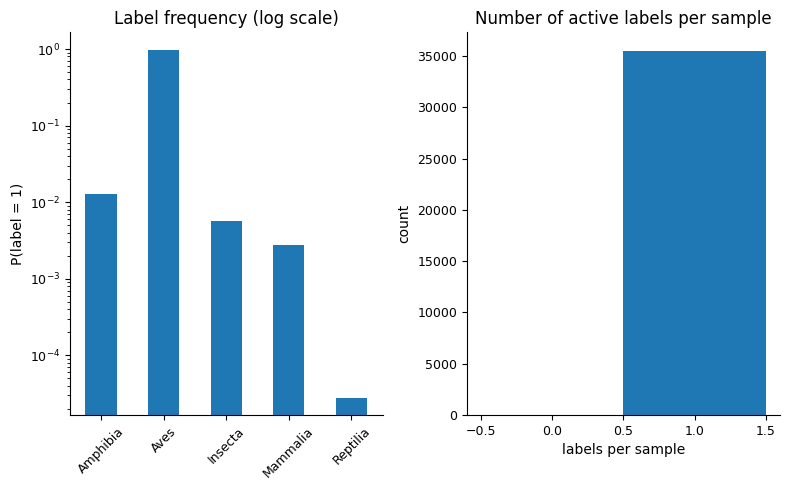

In [8]:
fig, axes = plt.subplots(1,2)
plot_label_frequency(y_class, ax=axes[0])
plot_active_labels(y_class, ax=axes[1])
plt.tight_layout()
plt.show()

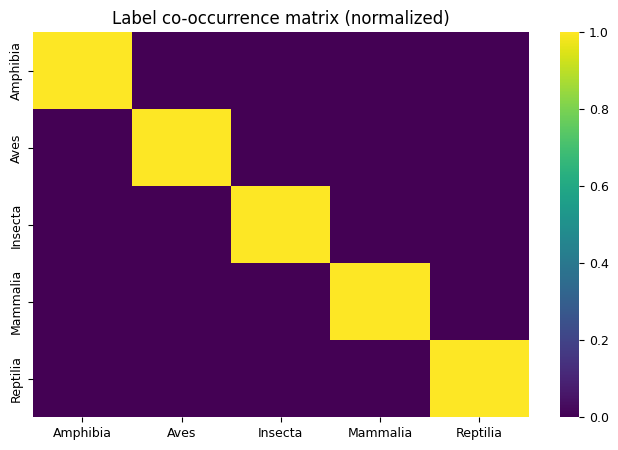

In [9]:
plot_label_concurrence(y_class)

### Train soundscapes

Resemble the test data.

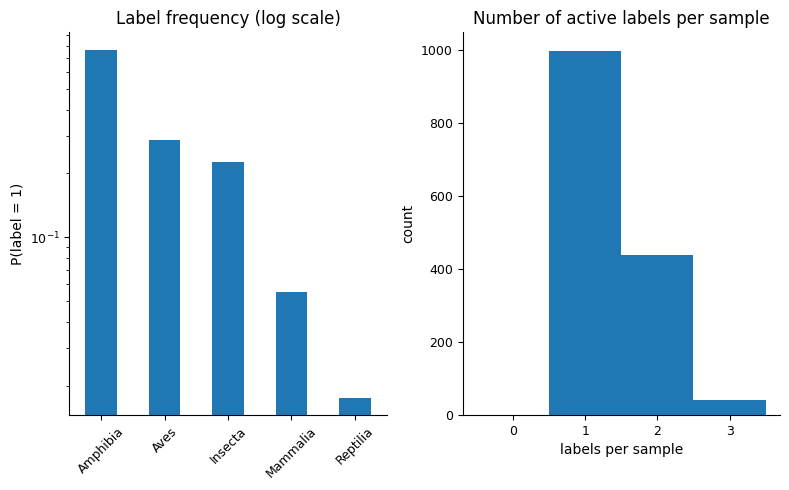

In [10]:
fig, axes = plt.subplots(1, 2)
plot_label_frequency(y_class_soundscapes, ax=axes[0])
plot_active_labels(y_class_soundscapes, ax=axes[1])
plt.tight_layout()
plt.show()

In [11]:
y_class_soundscapes.value_counts()

Amphibia  Aves  Insecta  Mammalia  Reptilia
1         0     0        0         0           866
          1     0        0         0           188
0         1     1        0         0           162
          0     1        0         0            78
1         0     1        0         0            46
0         1     0        0         0            30
1         1     0        1         0            26
0         0     0        1         0            24
                1        1         0            22
                         0         1            12
          1     1        0         1            12
1         0     0        1         0             4
0         1     0        1         0             4
1         1     1        0         0             2
0         0     1        1         1             2
Name: count, dtype: int64

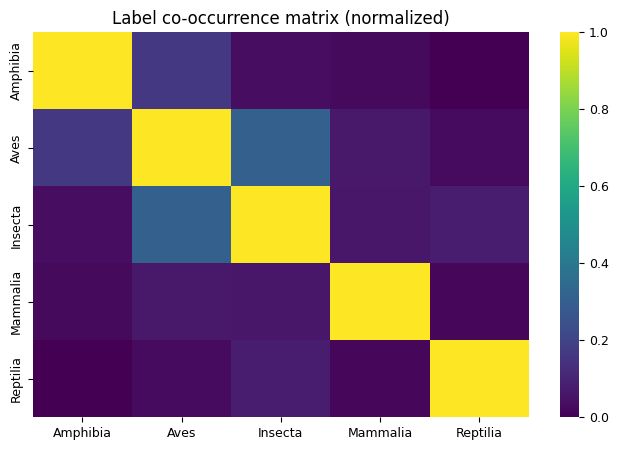

In [12]:
plot_label_concurrence(y_class_soundscapes)